In [1]:
import generate_graph


In [2]:
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve().parents[1]
print(project_root)
sys.path.insert(0, str(project_root))

import lib.dataloader as dl

/vol/data/immuneML/cmsb26_project7


In [18]:
df = dl.load_airr_dataset("repertoire_LigoSim_final_testing_variant_seed3_freq025_size50_noise25")
df

Loading cached dataset from /vol/data/immuneML/simulation_data/data/repertoire_LigoSim_final_testing_variant_seed3_freq025_size50_noise25/my_sim_inst/exported_dataset/airr/_dataset.pkl...


,sequence_id,sequence,quality,sequence_aa,rev_comp,productive,vj_in_frame,stop_codon,complete_vdj,locus,...,disease_signal_positions,signals_aggregated,original_sequence,original_p_gen,sample,disease_signal_y,disease,sim_item,filename,identifier
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TRB,...,m000100000000000000,disease_signal,CASSELRSSGGGTDTQYF,-1.0,b2bc338bf89843d39917992868954815,True,True,sim_item_disease,b2bc338bf89843d39917992868954815.tsv,b2bc338bf89843d39917992868954815
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TRB,...,m000010000000000,disease_signal,CSARDENPEGSPLHF,-1.0,b2bc338bf89843d39917992868954815,True,True,sim_item_disease,b2bc338bf89843d39917992868954815.tsv,b2bc338bf89843d39917992868954815
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TRB,...,m000000000100000000,disease_signal,CASSFPRQGSHWTDTQYF,-1.0,b2bc338bf89843d39917992868954815,True,True,sim_item_disease,b2bc338bf89843d39917992868954815.tsv,b2bc338bf89843d39917992868954815
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TRB,...,m00000000100000000,disease_signal,CASSYLGALVGYNEQFF,-1.0,b2bc338bf89843d39917992868954815,True,True,sim_item_disease,b2bc338bf89843d39917992868954815.tsv,b2bc338bf89843d39917992868954815
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TRB,...,m000000001000,disease_signal,CASSSGEGGYTF,-1.0,b2bc338bf89843d39917992868954815,True,True,sim_item_disease,b2bc338bf89843d39917992868954815.tsv,b2bc338bf89843d39917992868954815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TRB,...,m00000000000000,no_signal,NaN,-1.0,86690e51298149928134a3249ef7c2f9,True,False,sim_item_healthy,86690e51298149928134a3249ef7c2f9.tsv,86690e51298149928134a3249ef7c2f9
4996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TRB,...,m0000000000000000000,no_signal,NaN,-1.0,86690e51298149928134a3249ef7c2f9,True,False,sim_item_healthy,86690e51298149928134a3249ef7c2f9.tsv,86690e51298149928134a3249ef7c2f9
4997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TRB,...,m0000000000000,no_signal,NaN,-1.0,86690e51298149928134a3249ef7c2f9,True,False,sim_item_healthy,86690e51298149928134a3249ef7c2f9.tsv,86690e51298149928134a3249ef7c2f9
4998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TRB,...,m000000000000000000,no_signal,NaN,-1.0,86690e51298149928134a3249ef7c2f9,True,False,sim_item_healthy,86690e51298149928134a3249ef7c2f9.tsv,86690e51298149928134a3249ef7c2f9


In [19]:
# add templates column with just 1 values
df["templates"] = 1

# remove columns but original_sequence, templates, filename, identifier, disease, sample, repertoire_id
df = df[
    [
        "junction_aa",
        "templates",
        "filename",
        "disease",
        "sample",
        "repertoire_id",
    ]
]
df

,junction_aa,templates,filename,disease,sample,repertoire_id
0,CASGPKRSSGGGTDTQYF,1,b2bc338bf89843d39917992868954815.tsv,True,b2bc338bf89843d39917992868954815,b2bc338bf89843d39917992868954815
1,CSARGPKPEGSPLHF,1,b2bc338bf89843d39917992868954815.tsv,True,b2bc338bf89843d39917992868954815,b2bc338bf89843d39917992868954815
2,CASSFPRQGGPKTDTQYF,1,b2bc338bf89843d39917992868954815.tsv,True,b2bc338bf89843d39917992868954815,b2bc338bf89843d39917992868954815
3,CASSYLGAGPKYNEQFF,1,b2bc338bf89843d39917992868954815.tsv,True,b2bc338bf89843d39917992868954815,b2bc338bf89843d39917992868954815
4,CASSSGEGGPKF,1,b2bc338bf89843d39917992868954815.tsv,True,b2bc338bf89843d39917992868954815,b2bc338bf89843d39917992868954815
...,...,...,...,...,...,...
4995,CASRLSGWADTQYF,1,86690e51298149928134a3249ef7c2f9.tsv,False,86690e51298149928134a3249ef7c2f9,86690e51298149928134a3249ef7c2f9
4996,CASSPSKGRTSGGTYEQYF,1,86690e51298149928134a3249ef7c2f9.tsv,False,86690e51298149928134a3249ef7c2f9,86690e51298149928134a3249ef7c2f9
4997,CATSLVGRYEQYF,1,86690e51298149928134a3249ef7c2f9.tsv,False,86690e51298149928134a3249ef7c2f9,86690e51298149928134a3249ef7c2f9
4998,CASSYSAVDRVCNQPQHF,1,86690e51298149928134a3249ef7c2f9.tsv,False,86690e51298149928134a3249ef7c2f9,86690e51298149928134a3249ef7c2f9


In [20]:
df = generate_graph.top_percent_cutoff(df, p=0.01)
df = df.reset_index(drop=True)
df

# remove rows with nan
df = df.dropna()
df

,junction_aa,templates,filename,disease,sample,repertoire_id,cummulative_perc
0,CASGPKRSSGGGTDTQYF,1,b2bc338bf89843d39917992868954815.tsv,True,b2bc338bf89843d39917992868954815,b2bc338bf89843d39917992868954815,1.0
1,CSARGPKPEGSPLHF,1,b2bc338bf89843d39917992868954815.tsv,True,b2bc338bf89843d39917992868954815,b2bc338bf89843d39917992868954815,1.0
2,CASSFPRQGGPKTDTQYF,1,b2bc338bf89843d39917992868954815.tsv,True,b2bc338bf89843d39917992868954815,b2bc338bf89843d39917992868954815,1.0
3,CASSYLGAGPKYNEQFF,1,b2bc338bf89843d39917992868954815.tsv,True,b2bc338bf89843d39917992868954815,b2bc338bf89843d39917992868954815,1.0
4,CASSSGEGGPKF,1,b2bc338bf89843d39917992868954815.tsv,True,b2bc338bf89843d39917992868954815,b2bc338bf89843d39917992868954815,1.0
...,...,...,...,...,...,...,...
4995,CASRLSGWADTQYF,1,86690e51298149928134a3249ef7c2f9.tsv,False,86690e51298149928134a3249ef7c2f9,86690e51298149928134a3249ef7c2f9,1.0
4996,CASSPSKGRTSGGTYEQYF,1,86690e51298149928134a3249ef7c2f9.tsv,False,86690e51298149928134a3249ef7c2f9,86690e51298149928134a3249ef7c2f9,1.0
4997,CATSLVGRYEQYF,1,86690e51298149928134a3249ef7c2f9.tsv,False,86690e51298149928134a3249ef7c2f9,86690e51298149928134a3249ef7c2f9,1.0
4998,CASSYSAVDRVCNQPQHF,1,86690e51298149928134a3249ef7c2f9.tsv,False,86690e51298149928134a3249ef7c2f9,86690e51298149928134a3249ef7c2f9,1.0


In [6]:
df["sample"].value_counts()

sample
aacea128d8a94a33a816a5bbc4240372    100
717079719018418d8fe795f3fb3b2c09    100
751c8fd1b1074c82b30a6148a8f78168    100
07cca8e414c8444c912e9bd2a17152d2    100
9d06b09e58d2417493856184b0af6966    100
                                   ... 
b0f9a42d84f34b328bbefe8184a0ff6b    100
7108cbcf21684860904029c45fcd7edb    100
49b3c7f72c434fd6a39dc331236691b8    100
9c06728a0ec145e5873e8f993030a21e    100
c400abd7246447f58f675e7e0a6d0ed9    100
Name: count, Length: 150, dtype: int64

In [5]:
import numpy as np

import encoding.tcr_bert as tb

df_enc = tb.encode_sequences(df, seq_col="junction_aa", max_length=30)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: wukevin/tcr-bert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TCR-BERT loaded on cpu
['CASGPKRSSGGGTDTQYF', 'CSARGPKPEGSPLHF', 'CASSFPRQGGPKTDTQYF', 'CASSYLGAGPKYNEQFF', 'CASSSGEGGPKF', 'CASSAGGEIGPKYTF', 'CASGPKDLGQLSYEQYF', 'CASSQAQGLNTGPKFF', 'CASSLSNETGQRATDTGPK', 'CASSWKSGSIGASNQPGPK', 'CGPKADGEGQGPLGNTEAFF', 'CASSYSIPQGRGPKGNTIYF', 'CASDRGHGPKYTF', 'CASSGPKTSGRGGTDTQYF', 'CASSLPPGPKGTLHF', 'CASSLLRPGNGPKF', 'CASSLNPVAGAKNGPKF', 'CAGPKGELFF', 'CGPKLTWGRRSYEQYF', 'CAGPKRRIPDLYEQYF']
['C A S G P K R S S G G G T D T Q Y F', 'C S A R G P K P E G S P L H F', 'C A S S F P R Q G G P K T D T Q Y F', 'C A S S Y L G A G P K Y N E Q F F', 'C A S S S G E G G P K F', 'C A S S A G G E I G P K Y T F', 'C A S G P K D L G Q L S Y E Q Y F', 'C A S S Q A Q G L N T G P K F F', 'C A S S L S N E T G Q R A T D T G P K', 'C A S S W K S G S I G A S N Q P G P K', 'C G P K A D G E G Q G P L G N T E A F F', 'C A S S Y S I P Q G R G P K G N T I Y F', 'C A S D R G H G P K Y T F', 'C A S S G P K T S G R G G T D T Q Y F', 'C A S S L P P G P K G T L H F', 'C A S S L L R P G

Encoding sequences: 100%|██████████| 5/5 [00:49<00:00,  9.94s/it]


In [6]:
_, _, embeddings = df_enc

In [7]:
df["label_positive"] = df["disease"]
df["age"] = 'N'
df["sex"] = 'N'
df["study_group_description"] = 'N'

/tmp/ipykernel_1480469/2957376234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label_positive"] = df["disease"]
/tmp/ipykernel_1480469/2957376234.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age"] = 'N'
/tmp/ipykernel_1480469/2957376234.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

In [8]:
df_simplified = generate_graph.native_node_merge(df, embeddings, 100)

Samples processed: 1
Samples processed: 2
Samples processed: 3
Samples processed: 4
Samples processed: 5
Samples processed: 6
Samples processed: 7
Samples processed: 8
Samples processed: 9
Samples processed: 10
Samples processed: 11
Samples processed: 12
Samples processed: 13
Samples processed: 14
Samples processed: 15
Samples processed: 16
Samples processed: 17
Samples processed: 18
Samples processed: 19
Samples processed: 20
Samples processed: 21
Samples processed: 22
Samples processed: 23
Samples processed: 24
Samples processed: 25
Samples processed: 26
Samples processed: 27
Samples processed: 28
Samples processed: 29
Samples processed: 30
Samples processed: 31
Samples processed: 32
Samples processed: 33
Samples processed: 34
Samples processed: 35
Samples processed: 36
Samples processed: 37
Samples processed: 38
Samples processed: 39
Samples processed: 40
Samples processed: 41
Samples processed: 42
Samples processed: 43
Samples processed: 44
Samples processed: 45
Samples processed: 

In [11]:
df_simplified

,cluster,templates,cluster_embedding,sample,filename,label_positive,study_group_description,sex,age
0,0,1,"[0.5287724733352661, 1.1933729648590088, -0.81...",aacea128d8a94a33a816a5bbc4240372,aacea128d8a94a33a816a5bbc4240372.tsv,True,N,N,N
1,1,1,"[1.6199183464050293, 0.05746207758784294, 0.71...",aacea128d8a94a33a816a5bbc4240372,aacea128d8a94a33a816a5bbc4240372.tsv,True,N,N,N
2,2,1,"[1.9099384546279907, 0.36186066269874567, 0.22...",aacea128d8a94a33a816a5bbc4240372,aacea128d8a94a33a816a5bbc4240372.tsv,True,N,N,N
3,3,1,"[0.7191081047058105, 0.3649057745933532, 0.910...",aacea128d8a94a33a816a5bbc4240372,aacea128d8a94a33a816a5bbc4240372.tsv,True,N,N,N
4,4,1,"[2.4870550632476807, -0.9137073159217834, -0.8...",aacea128d8a94a33a816a5bbc4240372,aacea128d8a94a33a816a5bbc4240372.tsv,True,N,N,N
...,...,...,...,...,...,...,...,...,...
14995,95,1,"[1.6436936855316162, 0.1809533834457397, -0.63...",c400abd7246447f58f675e7e0a6d0ed9,c400abd7246447f58f675e7e0a6d0ed9.tsv,False,N,N,N
14996,96,1,"[1.4524775743484497, -1.788208246231079, 0.515...",c400abd7246447f58f675e7e0a6d0ed9,c400abd7246447f58f675e7e0a6d0ed9.tsv,False,N,N,N
14997,97,1,"[1.5529779195785522, -1.4645262956619263, 0.31...",c400abd7246447f58f675e7e0a6d0ed9,c400abd7246447f58f675e7e0a6d0ed9.tsv,False,N,N,N
14998,98,1,"[0.9825620651245117, -0.1821618676185608, 0.03...",c400abd7246447f58f675e7e0a6d0ed9,c400abd7246447f58f675e7e0a6d0ed9.tsv,False,N,N,N


In [9]:
from sklearn.neighbors import kneighbors_graph
import numpy as np
import torch
from torch_geometric.data import Data
from scipy.spatial.distance import cosine as cosine_distance


def build_knn_tcr_graph(cluster_embeddings, frequencies, k=10):
    num_clusters = len(cluster_embeddings)
    
    # Node features (with frequency)
    freq_normalized = (frequencies / frequencies.sum()).reshape(-1, 1)
    node_features = torch.cat([
        torch.tensor(cluster_embeddings, dtype=torch.float),
        torch.tensor(freq_normalized, dtype=torch.float)
    ], dim=1)
    
    # Create KNN graph
    knn = kneighbors_graph(cluster_embeddings, k, mode='connectivity', 
                          include_self=False, metric='cosine')
    
    # Convert to edge_index format
    edges = []
    edge_weights = []
    
    for i in range(num_clusters):
        neighbors = knn[i].nonzero()[1]
        for j in neighbors:
            edges.append([i, j])
            # Calculate similarity for edge weight
            sim = 1 - cosine_distance(cluster_embeddings[i], cluster_embeddings[j])
            edge_weights.append(sim)
    
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_weights, dtype=torch.float).unsqueeze(1)
    
    return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr)

In [10]:
# build all graphs for each sample in df


def build_graphs_for_samples(df, k=10):
    graphs = {}
    for sample_id, group in df.groupby("sample"):
        cluster_embeddings = np.array(group["cluster_embedding"].tolist())
        frequencies = group["templates"].values
        graph = build_knn_tcr_graph(cluster_embeddings, frequencies, k)
        # graph label either 0 or 1 based on bool in label_positive column
        graph.y = torch.tensor([1 if group["label_positive"].iloc[0] else 0], dtype=torch.long)
        graphs[sample_id] = graph
    return graphs

In [11]:
graphs_dict = build_graphs_for_samples(df_simplified, k=20)
dataset = list(graphs_dict.values())

In [12]:
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

train_data, val_data = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42,
    stratify=[data.y.item() for data in dataset]  # keeps class balance
)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=16, shuffle=False)

In [13]:
from torch_geometric.loader import DataLoader

batch_size = 16

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

in_dim = dataset[0].x.shape[1]  # embedding_dim + 1 frequency feature
hidden_dim = 16
num_classes = 1


In [14]:
import tcrGNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = tcrGNN.TCRgnn(in_dim, hidden_dim, num_classes).to(device)
model = tcrGNN.TCRgnnEdge(in_dim, hidden_dim, num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


train_labels = torch.tensor([data.y.item() for data in train_data])

# compute number of positive and negative samples
num_pos = (train_labels == 1).sum().item()
num_neg = (train_labels == 0).sum().item()

# pos_weight = (# negative samples) / (# positive samples)
pos_weight = torch.tensor(num_neg / num_pos).to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)


# criterion = torch.nn.BCEWithLogitsLoss()



In [15]:
import torch


def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch)          # shape: (batch_size, 1)
        out = out.view(-1)          # flatten to (batch_size,)
        y = batch.y.view(-1).float()  # ensure float for BCE
        
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)  # flatten
            y = batch.y.view(-1).float()
            
            pred = (torch.sigmoid(out) > 0.5).float()
            
            correct += (pred == y).sum().item()
            total += y.size(0)
    
    return correct / total

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)
            y = batch.y.view(-1).float()
            
            loss = criterion(out, y)
            total_loss += loss.item()
    
    return total_loss / len(loader)



In [16]:
from sklearn.metrics import roc_auc_score, roc_curve
import torch

def evaluate_auc(model, loader, device):
    model.eval()
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)
            
            probs = torch.sigmoid(out)  # convert logits to probability
            all_probs.append(probs.cpu())
            all_labels.append(batch.y.view(-1).cpu())
    
    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    auc = roc_auc_score(all_labels, all_probs)
    return auc, all_labels, all_probs

def plot_roc(all_labels, all_probs):
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Validation ROC Curve")
    plt.show()



Epoch 001 | Train Loss: 0.6934 | Train Acc: 0.6333 | Val Loss: 0.6924 | Val Acc: 0.4667 | Val AUC: 0.5956 | Precision: 0.4444 | Recall: 0.2667


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 002 | Train Loss: 0.7052 | Train Acc: 0.5000 | Val Loss: 0.6935 | Val Acc: 0.5000 | Val AUC: 0.5556 | Precision: 0.0000 | Recall: 0.0000


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 003 | Train Loss: 0.6859 | Train Acc: 0.5000 | Val Loss: 0.6937 | Val Acc: 0.5000 | Val AUC: 0.6800 | Precision: 0.0000 | Recall: 0.0000


...

/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 008 | Train Loss: 0.6942 | Train Acc: 0.5000 | Val Loss: 0.6931 | Val Acc: 0.5000 | Val AUC: 0.6756 | Precision: 0.0000 | Recall: 0.0000


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 009 | Train Loss: 0.6928 | Train Acc: 0.5000 | Val Loss: 0.6924 | Val Acc: 0.5000 | Val AUC: 0.6933 | Precision: 0.0000 | Recall: 0.0000
Epoch 010 | Train Loss: 0.6983 | Train Acc: 0.5000 | Val Loss: 0.6923 | Val Acc: 0.5000 | Val AUC: 0.7067 | Precision: 0.0000 | Recall: 0.0000


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


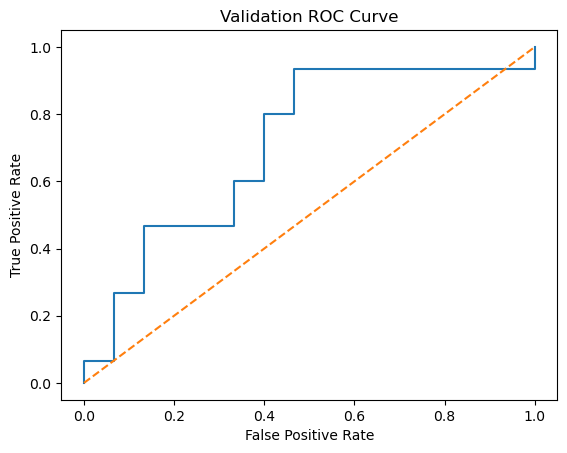

Confusion Matrix:
[[15  0]
 [15  0]]


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 011 | Train Loss: 0.6884 | Train Acc: 0.5083 | Val Loss: 0.6915 | Val Acc: 0.5000 | Val AUC: 0.6933 | Precision: 0.0000 | Recall: 0.0000


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 012 | Train Loss: 0.6936 | Train Acc: 0.5083 | Val Loss: 0.6908 | Val Acc: 0.5000 | Val AUC: 0.6933 | Precision: 0.0000 | Recall: 0.0000
Epoch 013 | Train Loss: 0.6838 | Train Acc: 0.5417 | Val Loss: 0.6885 | Val Acc: 0.5333 | Val AUC: 0.6978 | Precision: 1.0000 | Recall: 0.0667
Epoch 014 | Train Loss: 0.6904 | Train Acc: 0.7167 | Val Loss: 0.6821 | Val Acc: 0.7333 | Val AUC: 0.7289 | Precision: 0.7692 | Recall: 0.6667
Epoch 015 | Train Loss: 0.6729 | Train Acc: 0.6250 | Val Loss: 0.6717 | Val Acc: 0.6000 | Val AUC: 0.7422 | Precision: 0.5652 | Recall: 0.8667
Epoch 016 | Train Loss: 0.6618 | Train Acc: 0.6083 | Val Loss: 0.6486 | Val Acc: 0.6333 | Val AUC: 0.8000 | Precision: 0.5833 | Recall: 0.9333
Epoch 017 | Train Loss: 0.6500 | Train Acc: 0.7750 | Val Loss: 0.6342 | Val Acc: 0.8000 | Val AUC: 0.8267 | Precision: 0.7647 | Recall: 0.8667
Epoch 018 | Train Loss: 0.6290 | Train Acc: 0.7000 | Val Loss: 0.6124 | Val Acc: 0.7000 | Val AUC: 0.8133 | Precision: 0.6364 | Recall: 0.9333

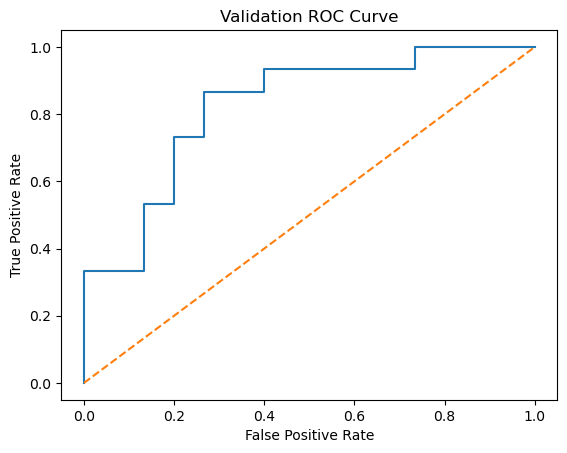

Confusion Matrix:
[[ 6  9]
 [ 1 14]]
Epoch 021 | Train Loss: 0.6084 | Train Acc: 0.7750 | Val Loss: 0.5891 | Val Acc: 0.7667 | Val AUC: 0.8356 | Precision: 0.7500 | Recall: 0.8000
Epoch 022 | Train Loss: 0.5496 | Train Acc: 0.8250 | Val Loss: 0.5277 | Val Acc: 0.8000 | Val AUC: 0.8578 | Precision: 0.8000 | Recall: 0.8000
Epoch 023 | Train Loss: 0.5190 | Train Acc: 0.7833 | Val Loss: 0.5061 | Val Acc: 0.8000 | Val AUC: 0.8400 | Precision: 0.8462 | Recall: 0.7333
Epoch 024 | Train Loss: 0.5586 | Train Acc: 0.6333 | Val Loss: 0.6370 | Val Acc: 0.5667 | Val AUC: 0.8756 | Precision: 1.0000 | Recall: 0.1333
Epoch 025 | Train Loss: 0.4714 | Train Acc: 0.8833 | Val Loss: 0.4624 | Val Acc: 0.8333 | Val AUC: 0.8756 | Precision: 0.7778 | Recall: 0.9333
Epoch 026 | Train Loss: 0.5097 | Train Acc: 0.7250 | Val Loss: 0.5428 | Val Acc: 0.6667 | Val AUC: 0.8800 | Precision: 0.8571 | Recall: 0.4000
Epoch 027 | Train Loss: 0.4608 | Train Acc: 0.7917 | Val Loss: 0.4928 | Val Acc: 0.7667 | Val AUC: 0.8578

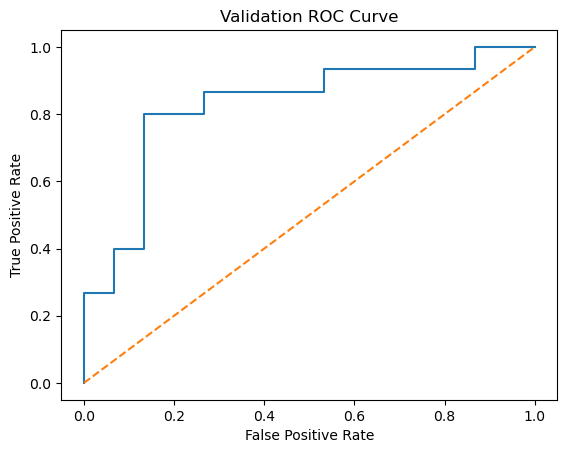

Confusion Matrix:
[[14  1]
 [10  5]]
Epoch 031 | Train Loss: 0.3355 | Train Acc: 0.8667 | Val Loss: 0.4365 | Val Acc: 0.7667 | Val AUC: 0.8889 | Precision: 0.8333 | Recall: 0.6667
Epoch 032 | Train Loss: 0.3048 | Train Acc: 0.9333 | Val Loss: 0.4343 | Val Acc: 0.8333 | Val AUC: 0.9022 | Precision: 0.7778 | Recall: 0.9333
Epoch 033 | Train Loss: 0.3026 | Train Acc: 0.9417 | Val Loss: 0.3962 | Val Acc: 0.9000 | Val AUC: 0.8978 | Precision: 0.8750 | Recall: 0.9333
Epoch 034 | Train Loss: 0.2348 | Train Acc: 0.9667 | Val Loss: 0.3821 | Val Acc: 0.9000 | Val AUC: 0.9067 | Precision: 0.8750 | Recall: 0.9333
Epoch 035 | Train Loss: 0.2568 | Train Acc: 0.9833 | Val Loss: 0.3851 | Val Acc: 0.9000 | Val AUC: 0.9022 | Precision: 0.8750 | Recall: 0.9333
Epoch 036 | Train Loss: 0.2162 | Train Acc: 0.9833 | Val Loss: 0.4157 | Val Acc: 0.8667 | Val AUC: 0.8889 | Precision: 0.8667 | Recall: 0.8667
Epoch 037 | Train Loss: 0.1860 | Train Acc: 0.9583 | Val Loss: 0.4206 | Val Acc: 0.8667 | Val AUC: 0.9067

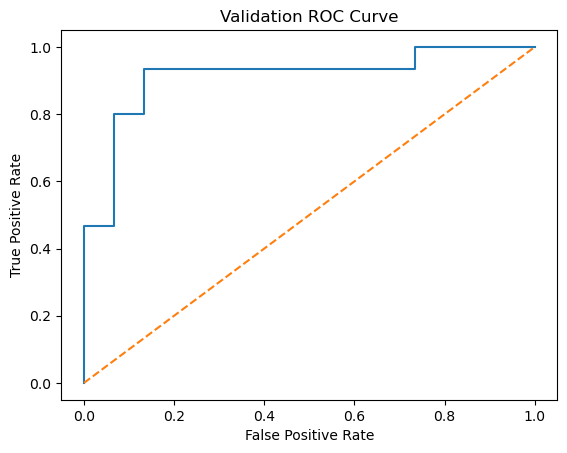

Confusion Matrix:
[[ 9  6]
 [ 1 14]]
Epoch 041 | Train Loss: 0.2160 | Train Acc: 0.9083 | Val Loss: 0.6040 | Val Acc: 0.7667 | Val AUC: 0.9200 | Precision: 0.7000 | Recall: 0.9333
Epoch 042 | Train Loss: 0.3909 | Train Acc: 0.8083 | Val Loss: 0.8319 | Val Acc: 0.6333 | Val AUC: 0.9378 | Precision: 0.5833 | Recall: 0.9333
Epoch 043 | Train Loss: 0.3365 | Train Acc: 0.7250 | Val Loss: 0.5548 | Val Acc: 0.7667 | Val AUC: 0.9200 | Precision: 1.0000 | Recall: 0.5333
Epoch 044 | Train Loss: 0.3401 | Train Acc: 0.9833 | Val Loss: 0.3655 | Val Acc: 0.8667 | Val AUC: 0.9333 | Precision: 0.8235 | Recall: 0.9333
Epoch 045 | Train Loss: 0.2763 | Train Acc: 0.9167 | Val Loss: 0.4458 | Val Acc: 0.8000 | Val AUC: 0.9289 | Precision: 0.7368 | Recall: 0.9333
Epoch 046 | Train Loss: 0.3765 | Train Acc: 0.9583 | Val Loss: 0.3439 | Val Acc: 0.9000 | Val AUC: 0.9422 | Precision: 1.0000 | Recall: 0.8000
Epoch 047 | Train Loss: 0.2503 | Train Acc: 0.9917 | Val Loss: 0.3432 | Val Acc: 0.9000 | Val AUC: 0.9378

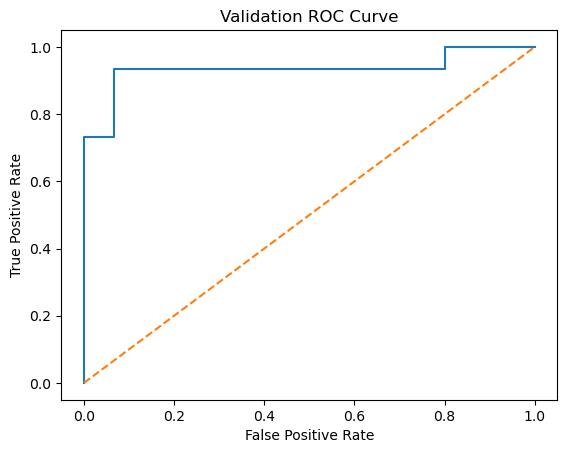

Confusion Matrix:
[[15  0]
 [ 4 11]]
Epoch 051 | Train Loss: 0.1343 | Train Acc: 0.9917 | Val Loss: 0.3204 | Val Acc: 0.9000 | Val AUC: 0.9333 | Precision: 0.8750 | Recall: 0.9333
Epoch 052 | Train Loss: 0.1111 | Train Acc: 0.9333 | Val Loss: 0.5937 | Val Acc: 0.7333 | Val AUC: 0.9378 | Precision: 0.6522 | Recall: 1.0000
Epoch 053 | Train Loss: 0.1992 | Train Acc: 0.8750 | Val Loss: 0.9591 | Val Acc: 0.6333 | Val AUC: 0.9422 | Precision: 0.5769 | Recall: 1.0000
Epoch 054 | Train Loss: 0.1943 | Train Acc: 0.9917 | Val Loss: 0.4259 | Val Acc: 0.8000 | Val AUC: 0.9289 | Precision: 0.7368 | Recall: 0.9333
Epoch 055 | Train Loss: 0.1158 | Train Acc: 0.9667 | Val Loss: 0.4650 | Val Acc: 0.8667 | Val AUC: 0.9111 | Precision: 1.0000 | Recall: 0.7333
Epoch 056 | Train Loss: 0.0987 | Train Acc: 0.9917 | Val Loss: 0.4087 | Val Acc: 0.8667 | Val AUC: 0.9244 | Precision: 0.8235 | Recall: 0.9333
Epoch 057 | Train Loss: 0.1231 | Train Acc: 0.9917 | Val Loss: 0.6296 | Val Acc: 0.8000 | Val AUC: 0.9333

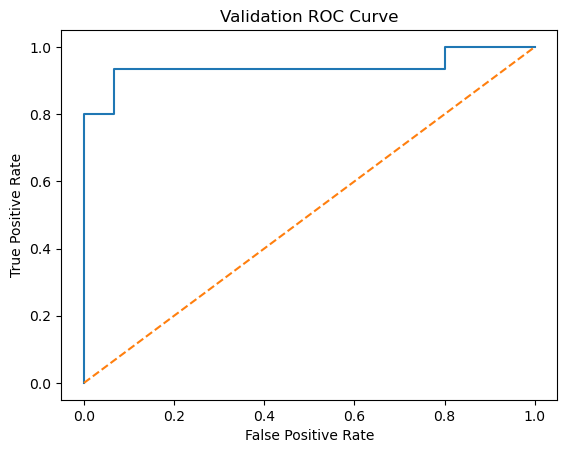

Confusion Matrix:
[[11  4]
 [ 1 14]]
Epoch 061 | Train Loss: 0.0626 | Train Acc: 0.9333 | Val Loss: 0.6195 | Val Acc: 0.8000 | Val AUC: 0.9244 | Precision: 1.0000 | Recall: 0.6000
Epoch 062 | Train Loss: 0.1047 | Train Acc: 0.9333 | Val Loss: 1.0070 | Val Acc: 0.6333 | Val AUC: 0.9289 | Precision: 0.5833 | Recall: 0.9333
Epoch 063 | Train Loss: 0.1173 | Train Acc: 0.9917 | Val Loss: 0.3982 | Val Acc: 0.8333 | Val AUC: 0.9156 | Precision: 1.0000 | Recall: 0.6667
Epoch 064 | Train Loss: 0.1017 | Train Acc: 0.9917 | Val Loss: 0.3415 | Val Acc: 0.8667 | Val AUC: 0.9289 | Precision: 0.8235 | Recall: 0.9333
Epoch 065 | Train Loss: 0.0702 | Train Acc: 0.9750 | Val Loss: 0.7069 | Val Acc: 0.7667 | Val AUC: 0.9422 | Precision: 0.6818 | Recall: 1.0000
Epoch 066 | Train Loss: 0.0640 | Train Acc: 0.9917 | Val Loss: 0.4937 | Val Acc: 0.8333 | Val AUC: 0.9289 | Precision: 0.9167 | Recall: 0.7333
Epoch 067 | Train Loss: 0.0588 | Train Acc: 0.9917 | Val Loss: 0.4169 | Val Acc: 0.8667 | Val AUC: 0.9289

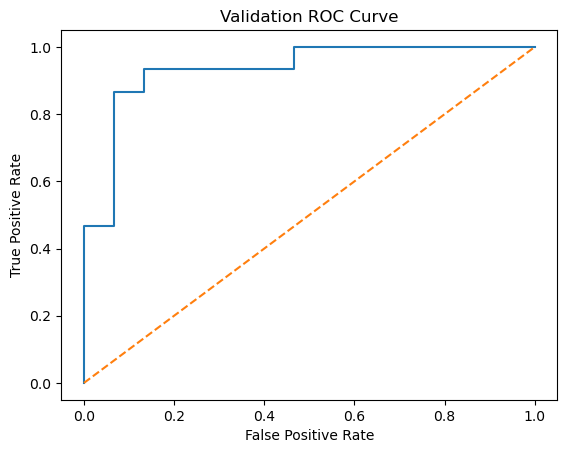

Confusion Matrix:
[[11  4]
 [ 1 14]]
Epoch 071 | Train Loss: 0.0808 | Train Acc: 0.9917 | Val Loss: 0.3629 | Val Acc: 0.8667 | Val AUC: 0.9378 | Precision: 0.8667 | Recall: 0.8667
Epoch 072 | Train Loss: 0.0609 | Train Acc: 0.9583 | Val Loss: 0.4163 | Val Acc: 0.8667 | Val AUC: 0.9422 | Precision: 0.9231 | Recall: 0.8000
Epoch 073 | Train Loss: 0.1285 | Train Acc: 1.0000 | Val Loss: 0.3867 | Val Acc: 0.9000 | Val AUC: 0.9378 | Precision: 0.8750 | Recall: 0.9333
Epoch 074 | Train Loss: 0.0300 | Train Acc: 1.0000 | Val Loss: 0.3795 | Val Acc: 0.9000 | Val AUC: 0.9333 | Precision: 0.9286 | Recall: 0.8667
Epoch 075 | Train Loss: 0.0499 | Train Acc: 1.0000 | Val Loss: 0.4030 | Val Acc: 0.9000 | Val AUC: 0.9378 | Precision: 0.8750 | Recall: 0.9333
Epoch 076 | Train Loss: 0.0245 | Train Acc: 1.0000 | Val Loss: 0.4208 | Val Acc: 0.8333 | Val AUC: 0.9467 | Precision: 0.7778 | Recall: 0.9333
Epoch 077 | Train Loss: 0.0197 | Train Acc: 1.0000 | Val Loss: 0.3778 | Val Acc: 0.9000 | Val AUC: 0.9422

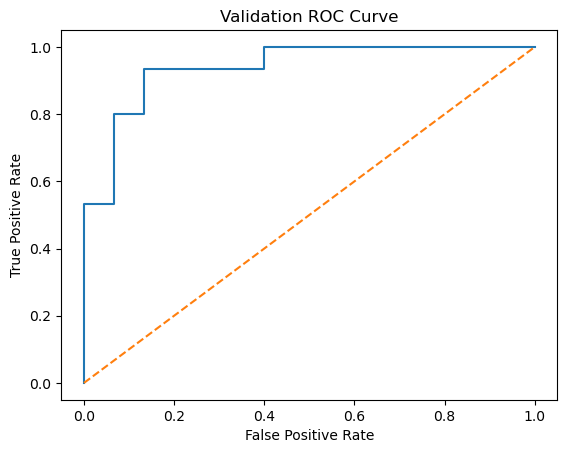

Confusion Matrix:
[[14  1]
 [ 4 11]]
Epoch 081 | Train Loss: 0.0167 | Train Acc: 1.0000 | Val Loss: 0.6331 | Val Acc: 0.8333 | Val AUC: 0.9467 | Precision: 0.7500 | Recall: 1.0000
Epoch 082 | Train Loss: 0.0184 | Train Acc: 1.0000 | Val Loss: 0.5082 | Val Acc: 0.8000 | Val AUC: 0.9333 | Precision: 0.9091 | Recall: 0.6667
Epoch 083 | Train Loss: 0.0187 | Train Acc: 1.0000 | Val Loss: 0.5614 | Val Acc: 0.8667 | Val AUC: 0.9467 | Precision: 0.7895 | Recall: 1.0000
Epoch 084 | Train Loss: 0.0274 | Train Acc: 1.0000 | Val Loss: 0.4277 | Val Acc: 0.8333 | Val AUC: 0.9333 | Precision: 0.8571 | Recall: 0.8000
Epoch 085 | Train Loss: 0.0388 | Train Acc: 1.0000 | Val Loss: 0.7022 | Val Acc: 0.8000 | Val AUC: 0.9244 | Precision: 0.7368 | Recall: 0.9333
Epoch 086 | Train Loss: 0.0212 | Train Acc: 0.9917 | Val Loss: 0.4160 | Val Acc: 0.8333 | Val AUC: 0.9289 | Precision: 0.8571 | Recall: 0.8000
Epoch 087 | Train Loss: 0.0874 | Train Acc: 1.0000 | Val Loss: 0.6693 | Val Acc: 0.8000 | Val AUC: 0.9378

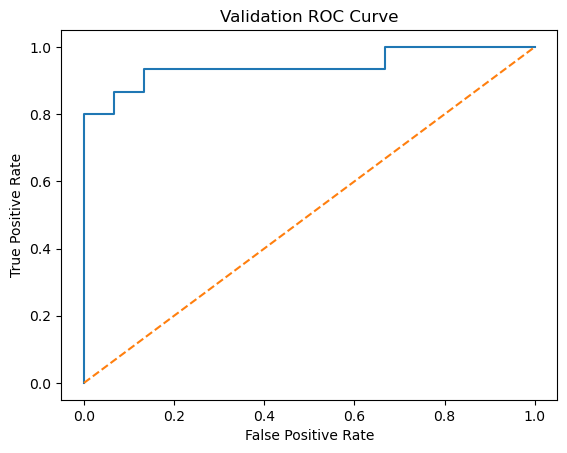

Confusion Matrix:
[[15  0]
 [ 6  9]]
Epoch 091 | Train Loss: 0.0484 | Train Acc: 0.9667 | Val Loss: 1.1152 | Val Acc: 0.6667 | Val AUC: 0.9556 | Precision: 0.6000 | Recall: 1.0000
Epoch 092 | Train Loss: 0.1683 | Train Acc: 1.0000 | Val Loss: 0.3653 | Val Acc: 0.8667 | Val AUC: 0.9467 | Precision: 0.8235 | Recall: 0.9333
Epoch 093 | Train Loss: 0.0900 | Train Acc: 0.9833 | Val Loss: 0.3638 | Val Acc: 0.8667 | Val AUC: 0.9467 | Precision: 1.0000 | Recall: 0.7333
Epoch 094 | Train Loss: 0.1523 | Train Acc: 0.9833 | Val Loss: 0.8441 | Val Acc: 0.7333 | Val AUC: 0.9511 | Precision: 0.6667 | Recall: 0.9333
Epoch 095 | Train Loss: 0.0569 | Train Acc: 0.9750 | Val Loss: 0.5095 | Val Acc: 0.8000 | Val AUC: 0.9467 | Precision: 1.0000 | Recall: 0.6000
Epoch 096 | Train Loss: 0.0878 | Train Acc: 0.9917 | Val Loss: 0.6425 | Val Acc: 0.8333 | Val AUC: 0.9511 | Precision: 0.7778 | Recall: 0.9333
Epoch 097 | Train Loss: 0.0225 | Train Acc: 0.9917 | Val Loss: 0.4837 | Val Acc: 0.8000 | Val AUC: 0.9156

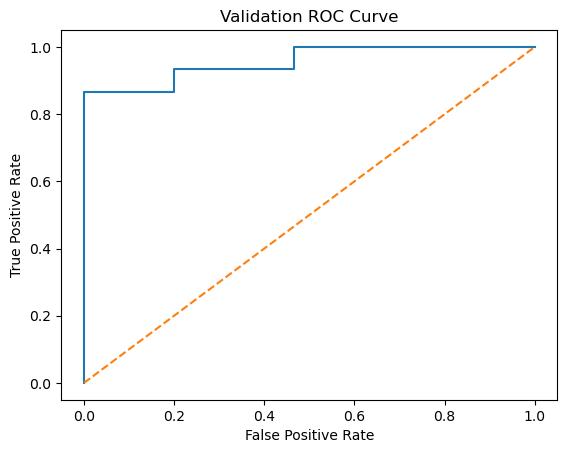

Confusion Matrix:
[[11  4]
 [ 1 14]]


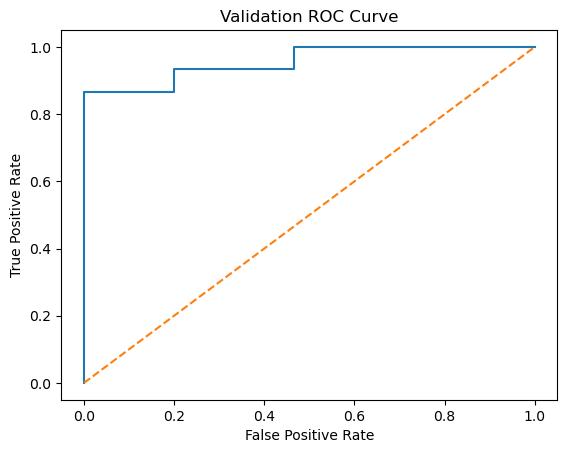

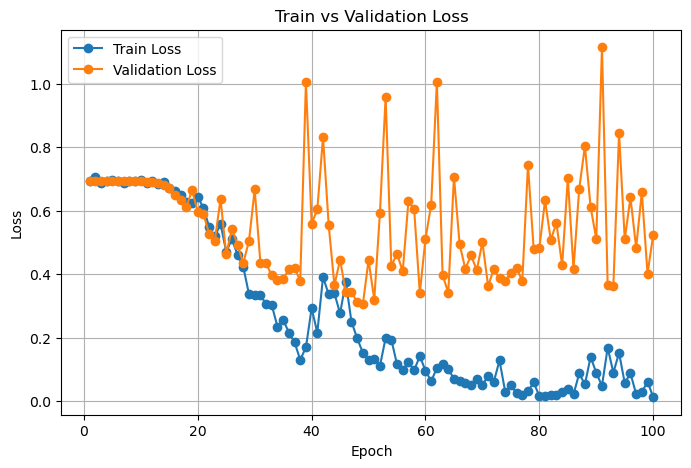

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import lib.metrics

num_epochs = 100

# store losses for plotting
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, criterion, device)
    train_acc  = evaluate(model, train_loader, device)
    val_loss   = evaluate_loss(model, val_loader, criterion, device)
    val_acc    = evaluate(model, val_loader, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    val_auc, labels, probs = evaluate_auc(model, val_loader, device)
    preds = (probs >= 0.5).astype(int)
    
    precision = precision_score(labels, preds)
    recall    = recall_score(labels, preds)
    cm        = confusion_matrix(labels, preds)
    
    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val AUC: {val_auc:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f}"
    )
    
    if (epoch+1) % 10 == 0:
        plot_roc(labels, probs)
        print("Confusion Matrix:")
        print(cm)

# Final ROC plot
plot_roc(labels, probs)

# --- Plot train and val loss ---
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


Epoch | Acc | Bal_Acc | Prec | Rec | AUROC | AUPRC | MCC
001 | Train Loss: 0.7938 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.8400 | 0.8762 | 0.0000
002 | Train Loss: 0.7300 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.8000 | 0.7100 | 0.0000
003 | Train Loss: 0.6979 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.3600 | 0.5657 | 0.0000
004 | Train Loss: 0.7508 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.3600 | 0.5657 | 0.0000
005 | Train Loss: 0.6892 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.5600 | 0.6533 | 0.0000
006 | Train Loss: 0.6902 | Train Acc: 0.5500 | 0.7000 | 0.7000 | 0.6667 | 0.8000 | 0.6400 | 0.6117 | 0.4082


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


007 | Train Loss: 0.7501 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.0000 | 0.0000 | 0.5600 | 0.6676 | 0.0000
008 | Train Loss: 0.6934 | Train Acc: 0.5750 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.6800 | 0.7833 | 0.0000


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


009 | Train Loss: 0.6878 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.0000 | 0.0000 | 0.8400 | 0.8762 | 0.0000
010 | Train Loss: 0.6671 | Train Acc: 0.6250 | 0.6000 | 0.6000 | 1.0000 | 0.2000 | 0.7600 | 0.8444 | 0.3333


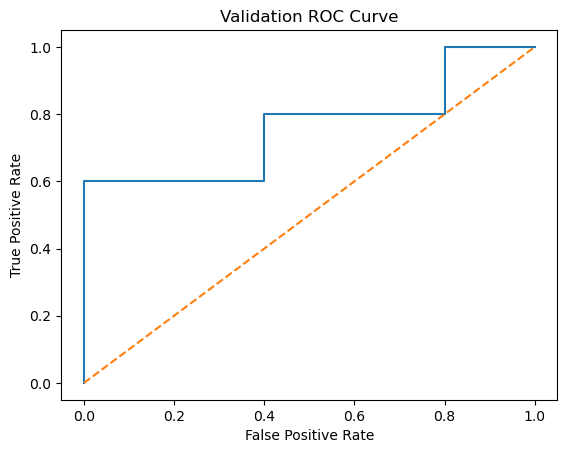

Confusion Matrix:
[[5 0]
 [4 1]]
011 | Train Loss: 0.6978 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.6000 | 0.6726 | 0.0000
012 | Train Loss: 0.6948 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.6000 | 0.7889 | 0.0000
013 | Train Loss: 0.7369 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.5600 | 0.7200 | 0.0000
014 | Train Loss: 0.6833 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.3600 | 0.4635 | 0.0000
015 | Train Loss: 0.6806 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.2000 | 0.4035 | 0.0000
016 | Train Loss: 0.6935 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.2000 | 0.4035 | 0.0000
017 | Train Loss: 0.6690 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.2000 | 0.4035 | 0.0000
018 | Train Loss: 0.6850 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.2000 | 0.4035 | 0.0000
019 | Train Loss: 0.7066 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.2800 | 0.4268 | 0.

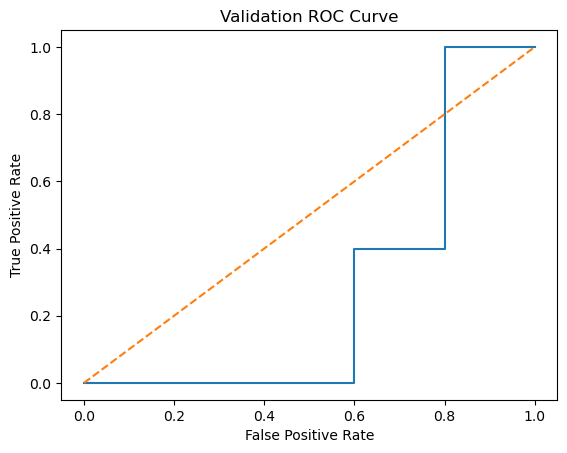

Confusion Matrix:
[[0 5]
 [0 5]]
021 | Train Loss: 0.7159 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.2800 | 0.4268 | 0.0000
022 | Train Loss: 0.6860 | Train Acc: 0.4750 | 0.5000 | 0.5000 | 0.5000 | 0.8000 | 0.3200 | 0.4411 | 0.0000


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


023 | Train Loss: 0.7106 | Train Acc: 0.5250 | 0.5000 | 0.5000 | 0.0000 | 0.0000 | 0.6000 | 0.6944 | 0.0000
024 | Train Loss: 0.7132 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.6400 | 0.7393 | 0.0000
025 | Train Loss: 0.6913 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.5200 | 0.6193 | 0.0000
026 | Train Loss: 0.7037 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.2800 | 0.4302 | 0.0000
027 | Train Loss: 0.6803 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.6800 | 0.7593 | 0.0000
028 | Train Loss: 0.6952 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.4000 | 0.5768 | 0.0000
029 | Train Loss: 0.6871 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.8800 | 0.8767 | 0.0000
030 | Train Loss: 0.6981 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.8800 | 0.9029 | 0.0000


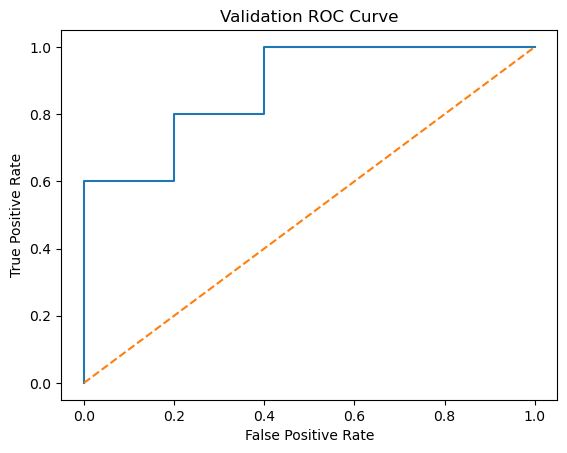

Confusion Matrix:
[[0 5]
 [0 5]]
031 | Train Loss: 0.6748 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.9600 | 0.9667 | 0.0000
032 | Train Loss: 0.6978 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.8000 | 0.8350 | 0.0000
033 | Train Loss: 0.6916 | Train Acc: 0.6750 | 0.6000 | 0.6000 | 1.0000 | 0.2000 | 0.9200 | 0.9429 | 0.3333


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


034 | Train Loss: 0.6881 | Train Acc: 0.5250 | 0.5000 | 0.5000 | 0.0000 | 0.0000 | 0.8800 | 0.9250 | 0.0000


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


035 | Train Loss: 0.7038 | Train Acc: 0.5250 | 0.5000 | 0.5000 | 0.0000 | 0.0000 | 0.8800 | 0.9029 | 0.0000
036 | Train Loss: 0.6848 | Train Acc: 0.7750 | 0.7000 | 0.7000 | 0.6250 | 1.0000 | 0.8800 | 0.9029 | 0.5000
037 | Train Loss: 0.6978 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.8400 | 0.8762 | 0.0000
038 | Train Loss: 0.6809 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.3600 | 0.5635 | 0.0000
039 | Train Loss: 0.6980 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.8400 | 0.8762 | 0.0000
040 | Train Loss: 0.7015 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.9200 | 0.9267 | 0.0000


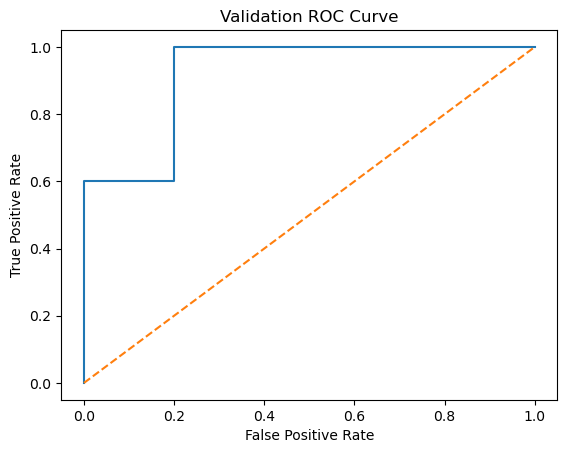

Confusion Matrix:
[[0 5]
 [0 5]]
041 | Train Loss: 0.6855 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.9200 | 0.9267 | 0.0000
042 | Train Loss: 0.6684 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.9600 | 0.9667 | 0.0000
043 | Train Loss: 0.6530 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.9600 | 0.9667 | 0.0000
044 | Train Loss: 0.6811 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 1.0000 | 1.0000 | 0.0000
045 | Train Loss: 0.7127 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 1.0000 | 1.0000 | 0.0000
046 | Train Loss: 0.6956 | Train Acc: 0.7250 | 0.7000 | 0.7000 | 0.6250 | 1.0000 | 0.9200 | 0.9267 | 0.5000


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


047 | Train Loss: 0.6762 | Train Acc: 0.5750 | 0.5000 | 0.5000 | 0.0000 | 0.0000 | 0.9200 | 0.9429 | 0.0000


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


048 | Train Loss: 0.6703 | Train Acc: 0.5500 | 0.5000 | 0.5000 | 0.0000 | 0.0000 | 0.9200 | 0.9429 | 0.0000
049 | Train Loss: 0.6794 | Train Acc: 0.6500 | 0.6000 | 0.6000 | 1.0000 | 0.2000 | 0.9600 | 0.9667 | 0.3333
050 | Train Loss: 0.6709 | Train Acc: 0.8500 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165


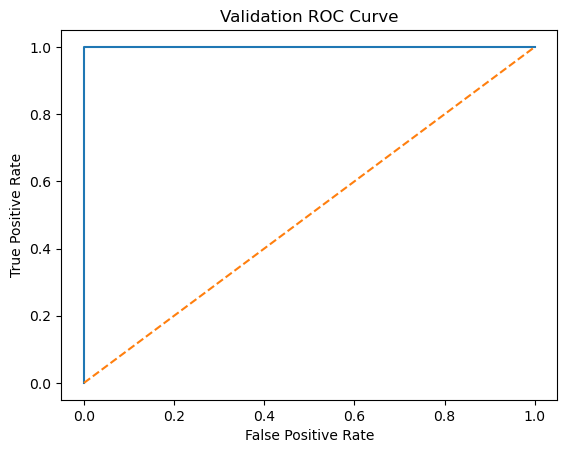

Confusion Matrix:
[[5 0]
 [1 4]]
051 | Train Loss: 0.6505 | Train Acc: 0.8000 | 0.8000 | 0.8000 | 0.7143 | 1.0000 | 1.0000 | 1.0000 | 0.6547
052 | Train Loss: 0.6658 | Train Acc: 0.5750 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 1.0000 | 1.0000 | 0.0000
053 | Train Loss: 0.5968 | Train Acc: 0.8000 | 0.8000 | 0.8000 | 0.7143 | 1.0000 | 1.0000 | 1.0000 | 0.6547
054 | Train Loss: 0.6217 | Train Acc: 0.8500 | 0.9000 | 0.9000 | 0.8333 | 1.0000 | 1.0000 | 1.0000 | 0.8165
055 | Train Loss: 0.5803 | Train Acc: 0.7250 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 1.0000 | 1.0000 | 0.0000
056 | Train Loss: 0.6016 | Train Acc: 0.7250 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 1.0000 | 1.0000 | 0.0000


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


057 | Train Loss: 0.5534 | Train Acc: 0.6000 | 0.5000 | 0.5000 | 0.0000 | 0.0000 | 1.0000 | 1.0000 | 0.0000
058 | Train Loss: 0.5211 | Train Acc: 0.8750 | 0.9000 | 0.9000 | 0.8333 | 1.0000 | 1.0000 | 1.0000 | 0.8165
059 | Train Loss: 0.5821 | Train Acc: 0.9000 | 0.9000 | 0.9000 | 0.8333 | 1.0000 | 1.0000 | 1.0000 | 0.8165
060 | Train Loss: 0.5520 | Train Acc: 0.8750 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000


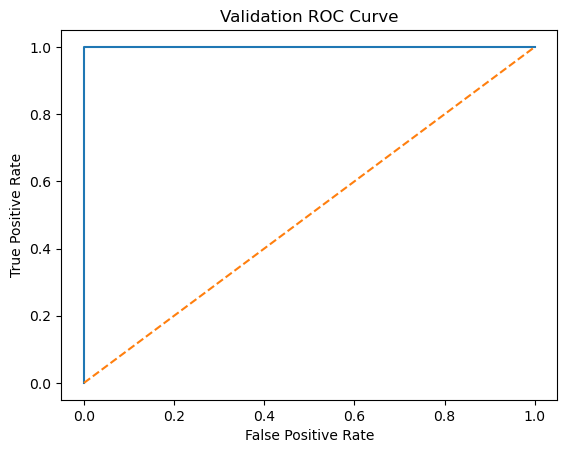

Confusion Matrix:
[[5 0]
 [0 5]]
061 | Train Loss: 0.4863 | Train Acc: 0.8750 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
062 | Train Loss: 0.4980 | Train Acc: 0.8250 | 0.9000 | 0.9000 | 0.8333 | 1.0000 | 1.0000 | 1.0000 | 0.8165
063 | Train Loss: 0.4756 | Train Acc: 0.7750 | 0.7000 | 0.7000 | 1.0000 | 0.4000 | 1.0000 | 1.0000 | 0.5000
064 | Train Loss: 0.4674 | Train Acc: 0.9500 | 0.9000 | 0.9000 | 0.8333 | 1.0000 | 1.0000 | 1.0000 | 0.8165
065 | Train Loss: 0.4767 | Train Acc: 0.8000 | 0.8000 | 0.8000 | 0.7143 | 1.0000 | 1.0000 | 1.0000 | 0.6547
066 | Train Loss: 0.3556 | Train Acc: 0.8750 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
067 | Train Loss: 0.5164 | Train Acc: 0.8250 | 0.8000 | 0.8000 | 1.0000 | 0.6000 | 1.0000 | 1.0000 | 0.6547
068 | Train Loss: 0.4569 | Train Acc: 0.8500 | 0.9000 | 0.9000 | 0.8333 | 1.0000 | 1.0000 | 1.0000 | 0.8165
069 | Train Loss: 0.4040 | Train Acc: 0.9500 | 0.9000 | 0.9000 | 0.8333 | 1.0000 | 1.0000 | 1.0000 | 0.

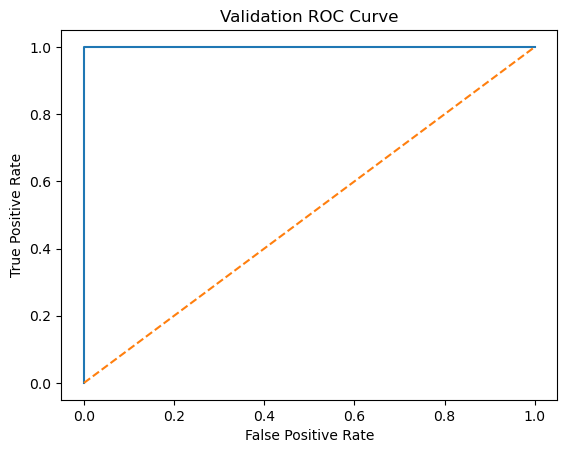

Confusion Matrix:
[[5 0]
 [0 5]]
071 | Train Loss: 0.3431 | Train Acc: 0.9500 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
072 | Train Loss: 0.3078 | Train Acc: 0.9500 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
073 | Train Loss: 0.2685 | Train Acc: 0.9750 | 0.9000 | 0.9000 | 0.8333 | 1.0000 | 1.0000 | 1.0000 | 0.8165
074 | Train Loss: 0.3482 | Train Acc: 0.9500 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
075 | Train Loss: 0.2308 | Train Acc: 0.7750 | 0.6000 | 0.6000 | 1.0000 | 0.2000 | 1.0000 | 1.0000 | 0.3333
076 | Train Loss: 0.3011 | Train Acc: 0.9750 | 0.9000 | 0.9000 | 0.8333 | 1.0000 | 1.0000 | 1.0000 | 0.8165
077 | Train Loss: 0.2568 | Train Acc: 0.9500 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
078 | Train Loss: 0.2310 | Train Acc: 0.9000 | 0.8000 | 0.8000 | 1.0000 | 0.6000 | 1.0000 | 1.0000 | 0.6547
079 | Train Loss: 0.1978 | Train Acc: 0.9750 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.

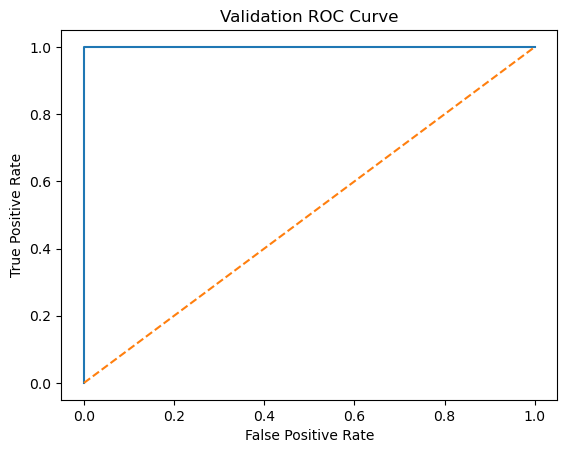

Confusion Matrix:
[[5 0]
 [0 5]]
081 | Train Loss: 0.2145 | Train Acc: 0.9750 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
082 | Train Loss: 0.1859 | Train Acc: 0.9750 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
083 | Train Loss: 0.1857 | Train Acc: 0.9500 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
084 | Train Loss: 0.3248 | Train Acc: 0.9750 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
085 | Train Loss: 0.2711 | Train Acc: 0.9750 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
086 | Train Loss: 0.1352 | Train Acc: 0.9000 | 0.7000 | 0.7000 | 1.0000 | 0.4000 | 1.0000 | 1.0000 | 0.5000
087 | Train Loss: 0.2470 | Train Acc: 0.9750 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
088 | Train Loss: 0.1900 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
089 | Train Loss: 0.0748 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.

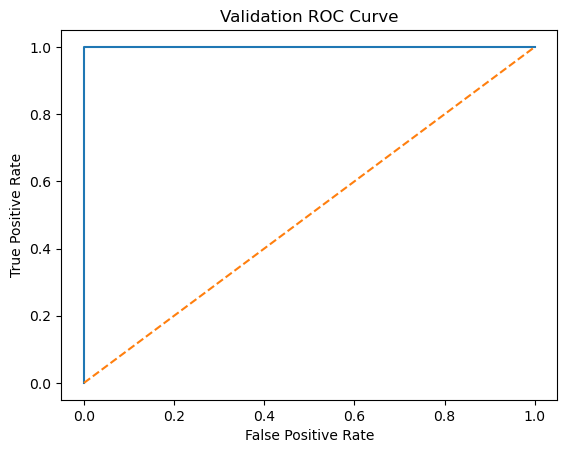

Confusion Matrix:
[[5 0]
 [0 5]]
091 | Train Loss: 0.1127 | Train Acc: 0.9750 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165
092 | Train Loss: 0.0731 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
093 | Train Loss: 0.1136 | Train Acc: 0.9750 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165
094 | Train Loss: 0.1018 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165
095 | Train Loss: 0.0454 | Train Acc: 0.9500 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
096 | Train Loss: 0.1024 | Train Acc: 0.9000 | 0.7000 | 0.7000 | 1.0000 | 0.4000 | 1.0000 | 1.0000 | 0.5000
097 | Train Loss: 0.1324 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165
098 | Train Loss: 0.0941 | Train Acc: 0.9750 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
099 | Train Loss: 0.1404 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.

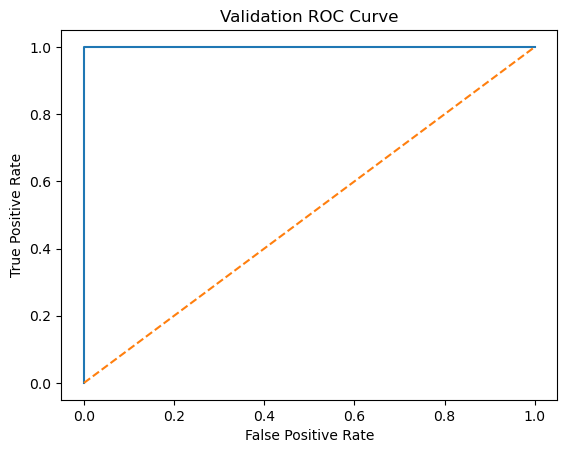

Confusion Matrix:
[[5 0]
 [2 3]]
101 | Train Loss: 0.1703 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165
102 | Train Loss: 0.1117 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
103 | Train Loss: 0.0854 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
104 | Train Loss: 0.0446 | Train Acc: 1.0000 | 0.7000 | 0.7000 | 1.0000 | 0.4000 | 1.0000 | 1.0000 | 0.5000
105 | Train Loss: 0.1014 | Train Acc: 1.0000 | 0.8000 | 0.8000 | 1.0000 | 0.6000 | 1.0000 | 1.0000 | 0.6547
106 | Train Loss: 0.0254 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
107 | Train Loss: 0.0613 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
108 | Train Loss: 0.0815 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
109 | Train Loss: 0.0229 | Train Acc: 1.0000 | 0.8000 | 0.8000 | 1.0000 | 0.6000 | 1.0000 | 1.0000 | 0.

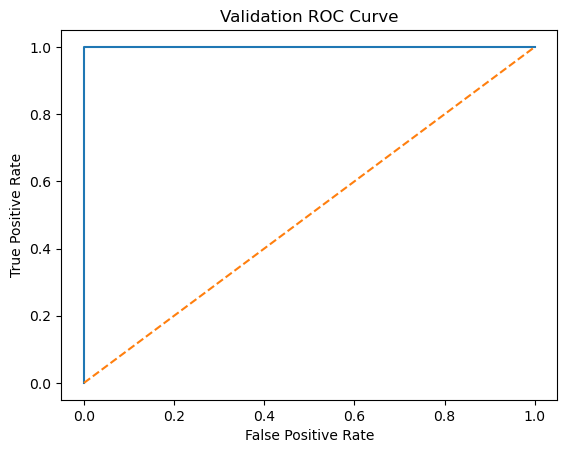

Confusion Matrix:
[[5 0]
 [2 3]]
111 | Train Loss: 0.0322 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
112 | Train Loss: 0.0468 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
113 | Train Loss: 0.0218 | Train Acc: 1.0000 | 0.8000 | 0.8000 | 1.0000 | 0.6000 | 1.0000 | 1.0000 | 0.6547
114 | Train Loss: 0.0159 | Train Acc: 0.9750 | 0.7000 | 0.7000 | 1.0000 | 0.4000 | 1.0000 | 1.0000 | 0.5000
115 | Train Loss: 0.0504 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
116 | Train Loss: 0.0294 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
117 | Train Loss: 0.0693 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
118 | Train Loss: 0.0523 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
119 | Train Loss: 0.0137 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.

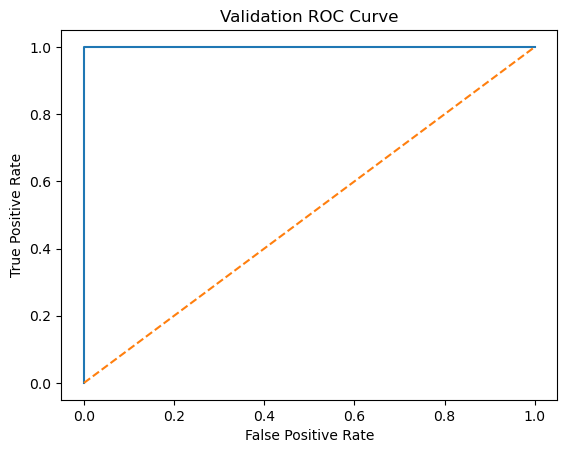

Confusion Matrix:
[[5 0]
 [2 3]]
121 | Train Loss: 0.0240 | Train Acc: 1.0000 | 0.8000 | 0.8000 | 1.0000 | 0.6000 | 1.0000 | 1.0000 | 0.6547
122 | Train Loss: 0.0522 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
123 | Train Loss: 0.0532 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
124 | Train Loss: 0.0211 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
125 | Train Loss: 0.0063 | Train Acc: 1.0000 | 0.8000 | 0.8000 | 1.0000 | 0.6000 | 1.0000 | 1.0000 | 0.6547
126 | Train Loss: 0.0414 | Train Acc: 1.0000 | 0.7000 | 0.7000 | 1.0000 | 0.4000 | 1.0000 | 1.0000 | 0.5000
127 | Train Loss: 0.1196 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
128 | Train Loss: 0.0268 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
129 | Train Loss: 0.0707 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.

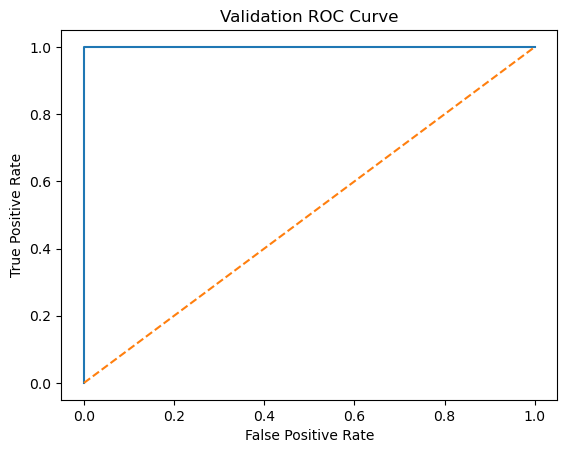

Confusion Matrix:
[[5 0]
 [2 3]]
131 | Train Loss: 0.0193 | Train Acc: 1.0000 | 0.7000 | 0.7000 | 1.0000 | 0.4000 | 1.0000 | 1.0000 | 0.5000
132 | Train Loss: 0.0174 | Train Acc: 1.0000 | 0.8000 | 0.8000 | 1.0000 | 0.6000 | 1.0000 | 1.0000 | 0.6547
133 | Train Loss: 0.0455 | Train Acc: 1.0000 | 0.8000 | 0.8000 | 1.0000 | 0.6000 | 1.0000 | 1.0000 | 0.6547
134 | Train Loss: 0.0216 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165
135 | Train Loss: 0.0420 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
136 | Train Loss: 0.0064 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
137 | Train Loss: 0.0737 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
138 | Train Loss: 0.0099 | Train Acc: 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000
139 | Train Loss: 0.0054 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.

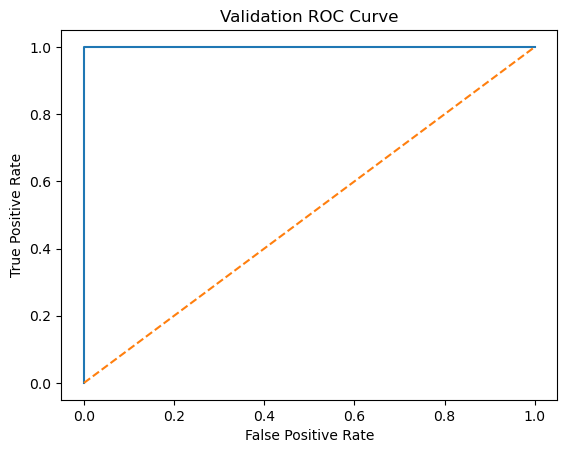

Confusion Matrix:
[[5 0]
 [1 4]]
141 | Train Loss: 0.0617 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165
142 | Train Loss: 0.0484 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165
143 | Train Loss: 0.0264 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165
144 | Train Loss: 0.0231 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165
145 | Train Loss: 0.0056 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165
146 | Train Loss: 0.0054 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165
147 | Train Loss: 0.0032 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165
148 | Train Loss: 0.0021 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.8165
149 | Train Loss: 0.0059 | Train Acc: 1.0000 | 0.9000 | 0.9000 | 1.0000 | 0.8000 | 1.0000 | 1.0000 | 0.

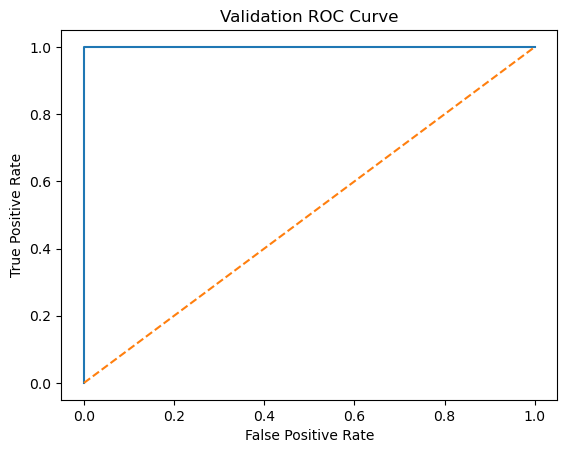

Confusion Matrix:
[[5 0]
 [0 5]]


In [17]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import lib.metrics

train_losses = []
val_losses = []
num_epochs = 150

print("Epoch | Acc | Bal_Acc | Prec | Rec | AUROC | AUPRC | MCC")

for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, criterion, device)
    train_acc  = evaluate(model, train_loader, device)
    val_loss   = evaluate_loss(model, val_loader, criterion, device)
    val_acc    = evaluate(model, val_loader, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    val_auc, labels, probs = evaluate_auc(model, val_loader, device)
    preds = (probs >= 0.5).astype(int)

    bal_acc = balanced_accuracy_score(labels, preds)
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    auprc = average_precision_score(labels, probs)
    mcc = matthews_corrcoef(labels, preds)
    
    cm = confusion_matrix(labels, preds)

    print(
        f"{epoch+1:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"{val_acc:.4f} | "
        f"{bal_acc:.4f} | "
        f"{precision:.4f} | "
        f"{recall:.4f} | "
        f"{val_auc:.4f} | "
        f"{auprc:.4f} | "
        f"{mcc:.4f}"
    )
    
    if (epoch+1) % 10 == 0:
        plot_roc(labels, probs)
        print("Confusion Matrix:")
        print(cm)

In [38]:
import torch

labels = torch.tensor([data.y.item() for data in dataset])

class_counts = torch.bincount(labels)
print("Class counts:", class_counts)

num_classes = len(class_counts)
total_samples = len(labels)

class_weights = total_samples / (num_classes * class_counts.float())
print("Class weights:", class_weights)


criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)


Class counts: tensor([610, 298])
Class weights: tensor([0.7443, 1.5235])


In [39]:
import torch

labels = torch.tensor([data.y.item() for data in dataset])

class_counts = torch.bincount(labels)
total_samples = len(labels)

majority_class_count = class_counts.max().item()

baseline_accuracy = majority_class_count / total_samples

print("Class counts:", class_counts.tolist())
print("Baseline accuracy:", baseline_accuracy)


Class counts: [610, 298]
Baseline accuracy: 0.6718061674008811
